# 99_analyze — Black-Litterman 실험 결과 분석

각 섹션은 **하나의 질문**에 답합니다.

| 섹션 | 질문 |
|---|---|
| **A** | 전체 결과가 어떻게 됐나? |
| **B** | BL 자체가 의미있나? (vs naive_lowvol, CAPM) |
| **C** | P 슬롯: Trailing vol vs LSTM, 가중 방식 |
| **D** | Q 슬롯: fixed vs lambda vs inv_lambda vs raw_lam vs ff3_paper |
| **E** | 최적 조합 상세 분석 |
| **F** | Trailing vs LSTM — 왜 성과 차이가 나는가? |
| **G** | Omega 슬롯: he_litterman vs 논문 방식 (ff3_paper) |
| **H** | 서브기간 강건성 분석 |
| **I** | Turnover & 거래비용 분석 |

In [57]:
import pickle
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.ticker as mtick
import warnings
import platform
from pathlib import Path

warnings.filterwarnings('ignore')
if platform.system() == 'Windows':
    plt.rcParams['font.family'] = 'Malgun Gothic'
plt.rcParams['axes.unicode_minus'] = False

RESULTS_DIR = Path.cwd() / 'results'
OUT_DIR     = Path.cwd() / 'outputs' / '99_analyze'
OUT_DIR.mkdir(parents=True, exist_ok=True)

# ── 결과 로드 ──────────────────────────────────────────────────
loaded = {}
for pkl in sorted(RESULTS_DIR.glob('*.pkl')):
    with open(pkl, 'rb') as f:
        loaded[pkl.stem] = pickle.load(f)

# ── rf 로드 ────────────────────────────────────────────────────
panel_rf = pd.read_csv(Path.cwd() / 'data' / 'monthly_panel.csv',
                       usecols=['date','ticker','rf_1m'], parse_dates=['date'])
rf = panel_rf.groupby('date')['rf_1m'].first()

spy_ret = loaded['baseline']['spy_ret'].dropna()

# ── 성과 계산 함수 ──────────────────────────────────────────────
def calc(name):
    r    = loaded[name]['ret'].dropna()
    rf_a = rf.reindex(r.index).fillna(0)
    exc  = r - rf_a
    ann  = exc.mean() * 12
    vol  = r.std() * np.sqrt(12)
    sh   = ann / vol if vol > 0 else np.nan
    cum  = (1 + r).cumprod()
    mdd  = ((cum / cum.cummax()) - 1).min()
    dsd  = r[r < 0].std() * np.sqrt(12)
    sor  = ann / dsd if dsd > 0 else np.nan
    tot  = cum.iloc[-1] - 1
    cagr = r.mean() * 12
    return dict(sharpe=sh, cagr=cagr, vol=vol, mdd=mdd,
                sortino=sor, total=tot, ret=r, cum=cum)

# SPY 성과
def calc_spy():
    r    = spy_ret
    rf_a = rf.reindex(r.index).fillna(0)
    exc  = r - rf_a
    ann  = exc.mean() * 12
    vol  = r.std() * np.sqrt(12)
    sh   = ann / vol
    cum  = (1 + r).cumprod()
    mdd  = ((cum / cum.cummax()) - 1).min()
    return dict(sharpe=sh, cagr=r.mean()*12, vol=vol, mdd=mdd, total=cum.iloc[-1]-1, cum=cum)

print(f'로드 완료: {len(loaded)}개 실험')
print(f'기간: {loaded["baseline"]["ret"].index[0].date()} ~ {loaded["baseline"]["ret"].index[-1].date()}')

로드 완료: 29개 실험
기간: 2010-01-31 ~ 2024-12-31


## A. 전체 결과 요약

> **19개 실험 한눈에 — Sharpe 기준 정렬**

In [58]:
# ── A1. 성과 테이블 ────────────────────────────────────────────
rows = []
for name in sorted(loaded.keys()):
    m = calc(name)
    rows.append(dict(
        실험명   = name,
        Sharpe   = round(m['sharpe'],  3),
        CAGR     = f"{m['cagr']*100:.1f}%",
        Vol      = f"{m['vol']*100:.1f}%",
        MDD      = f"{m['mdd']*100:.1f}%",
        Sortino  = round(m['sortino'], 3),
        누적수익 = f"{m['total']*100:.0f}%",
    ))

# SPY 추가
ms = calc_spy()
rows.append(dict(
    실험명='SPY', Sharpe=round(ms['sharpe'],3),
    CAGR=f"{ms['cagr']*100:.1f}%", Vol=f"{ms['vol']*100:.1f}%",
    MDD=f"{ms['mdd']*100:.1f}%", Sortino='-', 누적수익=f"{ms['total']*100:.0f}%"
))

df_tbl = pd.DataFrame(rows).set_index('실험명').sort_values('Sharpe', ascending=False)

def hl_sharpe(v):
    try:
        v = float(v)
        if v >= 1.15: return 'background-color:#c6efce;color:#276221;font-weight:bold'
        if v >= 1.05: return 'background-color:#ffeb9c;color:#9c5700'
        if v >= 0.95: return ''
        return 'background-color:#ffc7ce;color:#9c0006'
    except: return ''

display(df_tbl.style.applymap(hl_sharpe, subset=['Sharpe']))

,Sharpe,CAGR,Vol,MDD,Sortino,누적수익
실험명,,,,,,
omega_paper,1.122000,15.9%,13.1%,-15.7%,1.651000,839%
baseline,1.111000,13.4%,11.0%,-13.0%,1.762000,572%
prior_eq,1.111000,14.2%,11.7%,-13.9%,1.695000,653%
q_raw_lam,1.081000,13.3%,11.2%,-12.7%,1.978000,559%
q_inv_lambda,1.080000,13.5%,11.4%,-13.9%,1.529000,580%
q_lambda,1.072000,13.0%,11.0%,-12.7%,1.917000,534%
p_lstm_eq,1.068000,13.0%,11.0%,-12.6%,1.632000,531%
naive_lowvol,1.065000,13.9%,11.9%,-14.7%,1.569000,612%
p_rp,1.057000,12.8%,11.0%,-12.9%,1.658000,520%


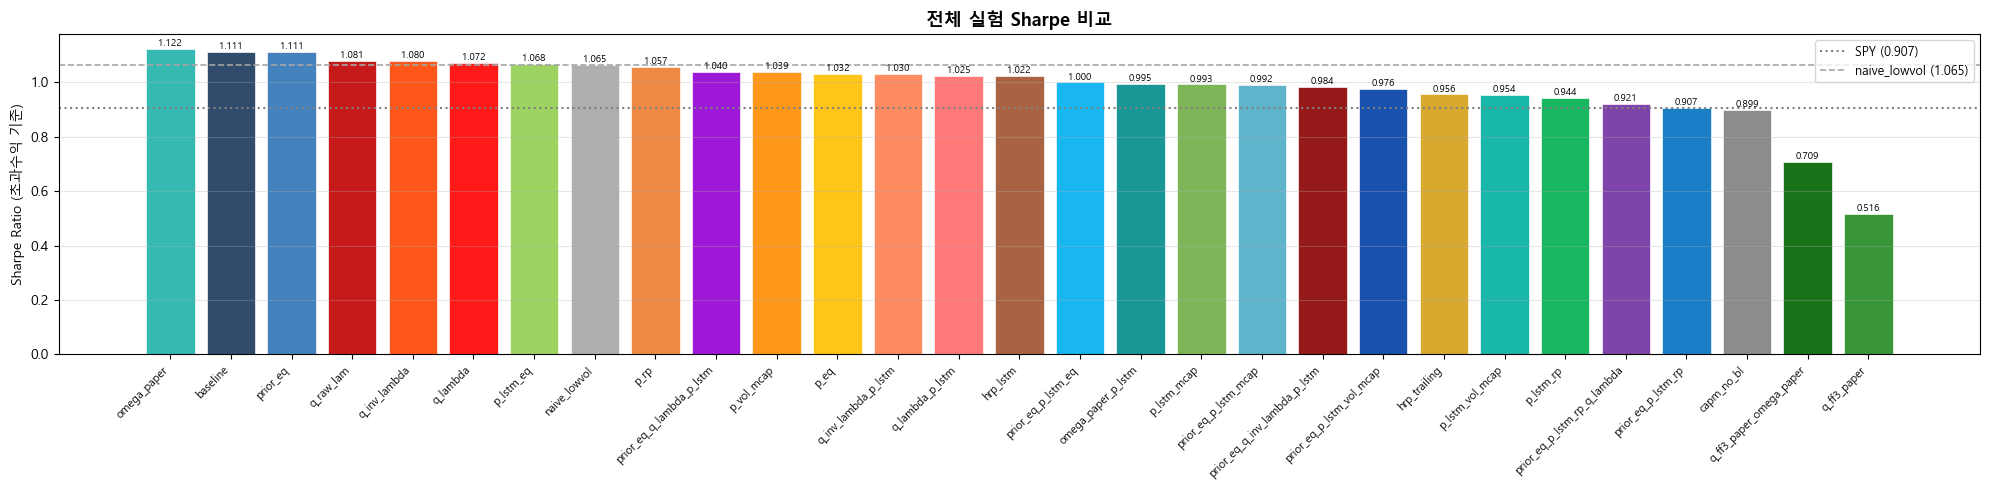

In [59]:
# ── A2. Sharpe 막대 차트 ───────────────────────────────────────
# 그룹별 색상
GROUP_COLOR = {
    # baseline / prior
    'baseline'                      : '#1A375C',
    'prior_eq'                      : '#2E75B6',
    # P 가중 방식 (Trailing)
    'p_rp'                          : '#ED7D31',
    'p_eq'                          : '#FFC000',
    'p_vol_mcap'                    : '#FF8C00',
    # P = LSTM (mcap prior)
    'p_lstm_mcap'                   : '#70AD47',
    'p_lstm_eq'                     : '#92D050',
    'p_lstm_rp'                     : '#00B050',
    'p_lstm_vol_mcap'               : '#00B0A0',
    # P = LSTM (eq prior)
    'prior_eq_p_lstm_mcap'          : '#4BACC6',
    'prior_eq_p_lstm_eq'            : '#00B0F0',
    'prior_eq_p_lstm_rp'            : '#0070C0',
    'prior_eq_p_lstm_vol_mcap'      : '#003EA5',
    # Q = lambda (정방향: 강세↑Q)
    'q_lambda'                      : '#FF0000',
    'q_raw_lam'                     : '#C00000',
    'q_lambda_p_lstm'               : '#FF6B6B',
    # Q = inv_lambda (역방향: 위기↑Q)
    'q_inv_lambda'                  : '#FF4500',
    'q_inv_lambda_p_lstm'           : '#FF7F50',
    # 최적 조합
    'prior_eq_p_lstm_rp_q_lambda'   : '#7030A0',
    'prior_eq_q_inv_lambda_p_lstm'  : '#8B0000',
    'prior_eq_q_lambda_p_lstm'      : '#9400D3',
    # Omega / FF3 논문 방식
    'q_ff3_paper'                   : '#228B22',
    'q_ff3_paper_omega_paper'       : '#006400',
    'omega_paper'                   : '#20B2AA',
    'omega_paper_p_lstm'            : '#008B8B',
    # HRP 비교군
    'hrp_trailing'                  : '#D4A017',
    'hrp_lstm'                      : '#A0522D',
    # 비교군
    'capm_no_bl'                    : '#808080',
    'naive_lowvol'                  : '#A5A5A5',
}

order = df_tbl.index.tolist()
names_plot = [n for n in order if n != 'SPY']
sharpes    = [calc(n)['sharpe'] for n in names_plot]
colors     = [GROUP_COLOR.get(n, '#BDBDBD') for n in names_plot]

fig, ax = plt.subplots(figsize=(20, 5))
bars = ax.bar(range(len(names_plot)), sharpes, color=colors, alpha=0.9, edgecolor='white', linewidth=0.5)
ax.axhline(calc_spy()['sharpe'], color='gray', linestyle=':', linewidth=1.5, label=f"SPY ({calc_spy()['sharpe']:.3f})")
ax.axhline(calc('naive_lowvol')['sharpe'], color='#A5A5A5', linestyle='--', linewidth=1.2,
           label=f"naive_lowvol ({calc('naive_lowvol')['sharpe']:.3f})")

for bar, v in zip(bars, sharpes):
    ax.text(bar.get_x()+bar.get_width()/2, v+0.003, f'{v:.3f}',
            ha='center', va='bottom', fontsize=7)

ax.set_xticks(range(len(names_plot)))
ax.set_xticklabels(names_plot, rotation=45, ha='right', fontsize=8)
ax.set_ylabel('Sharpe Ratio (초과수익 기준)')
ax.set_title('전체 실험 Sharpe 비교', fontweight='bold', fontsize=13)
ax.legend(fontsize=9); ax.grid(alpha=0.3, axis='y')
plt.tight_layout()
plt.savefig(OUT_DIR / 'A_sharpe_bar.png', dpi=150, bbox_inches='tight')
plt.show()

## B. BL이 의미있나?

> `naive_lowvol` (BL 없이 저변동 직접 보유) / `capm_no_bl` (CAPM 직접 최적화) / `baseline` (BL 적용)

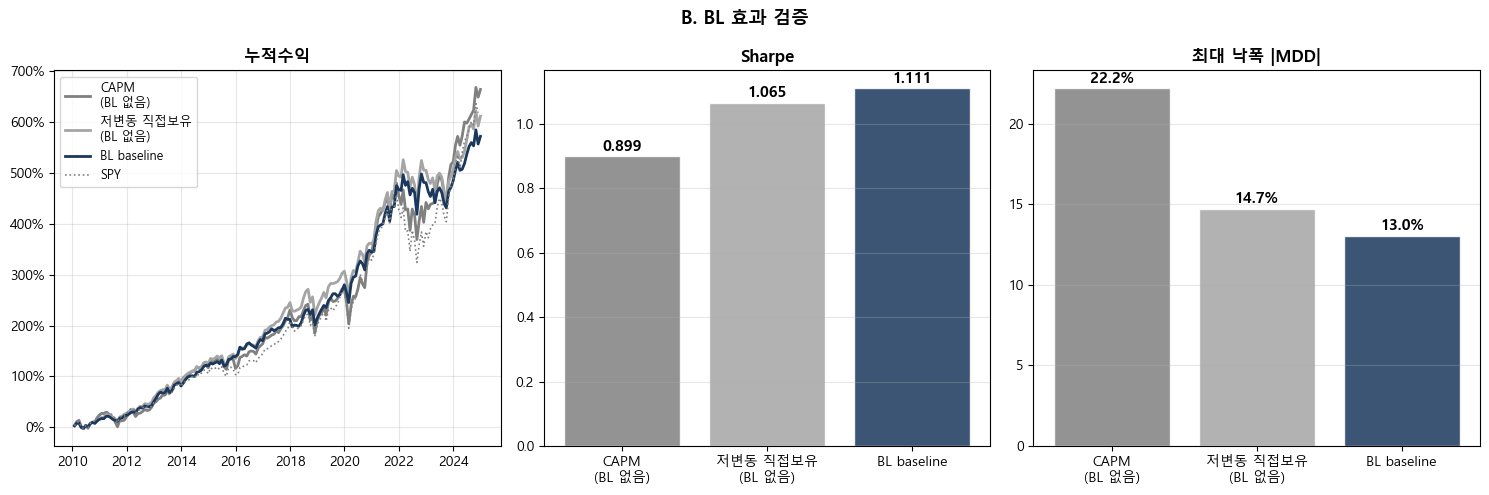

BL 추가 효과 (baseline vs naive_lowvol):
  Sharpe  : 1.065 → 1.111  (+0.046)
  MDD     : -14.7% → -13.0%  (+1.7%p)


In [60]:
bl_compare = ['capm_no_bl', 'naive_lowvol', 'baseline']
bl_labels  = ['CAPM\n(BL 없음)', '저변동 직접보유\n(BL 없음)', 'BL baseline']
bl_colors  = ['#808080', '#A5A5A5', '#1A375C']

fig, axes = plt.subplots(1, 3, figsize=(15, 5))

# 누적수익
ax = axes[0]
for name, label, c in zip(bl_compare, bl_labels, bl_colors):
    m = calc(name)
    ax.plot(m['cum'].index, m['cum'].values - 1, label=label, linewidth=2.0, color=c)
ax.plot(ms['cum'].index, ms['cum'].values - 1, label='SPY', linewidth=1.2,
        linestyle=':', color='gray')
ax.yaxis.set_major_formatter(mtick.PercentFormatter(xmax=1))
ax.set_title('누적수익', fontweight='bold'); ax.legend(fontsize=9); ax.grid(alpha=0.3)

# Sharpe 막대
ax = axes[1]
vals = [calc(n)['sharpe'] for n in bl_compare]
bars = ax.bar(bl_labels, vals, color=bl_colors, alpha=0.85, edgecolor='white')
for bar, v in zip(bars, vals):
    ax.text(bar.get_x()+bar.get_width()/2, v+0.005, f'{v:.3f}',
            ha='center', va='bottom', fontsize=11, fontweight='bold')
ax.set_title('Sharpe', fontweight='bold'); ax.grid(alpha=0.3, axis='y')

# MDD 막대 (절댓값)
ax = axes[2]
vals_mdd = [abs(calc(n)['mdd'])*100 for n in bl_compare]
bars = ax.bar(bl_labels, vals_mdd, color=bl_colors, alpha=0.85, edgecolor='white')
for bar, v in zip(bars, vals_mdd):
    ax.text(bar.get_x()+bar.get_width()/2, v+0.1, f'{v:.1f}%',
            ha='center', va='bottom', fontsize=11, fontweight='bold')
ax.set_title('최대 낙폭 |MDD|', fontweight='bold'); ax.grid(alpha=0.3, axis='y')

plt.suptitle('B. BL 효과 검증', fontsize=13, fontweight='bold')
plt.tight_layout()
plt.savefig(OUT_DIR / 'B_bl_effect.png', dpi=150, bbox_inches='tight')
plt.show()

m_b = calc('baseline'); m_n = calc('naive_lowvol')
print(f'BL 추가 효과 (baseline vs naive_lowvol):')
print(f'  Sharpe  : {m_n["sharpe"]:.3f} → {m_b["sharpe"]:.3f}  ({m_b["sharpe"]-m_n["sharpe"]:+.3f})')
print(f'  MDD     : {m_n["mdd"]*100:.1f}% → {m_b["mdd"]*100:.1f}%  ({(m_b["mdd"]-m_n["mdd"])*100:+.1f}%p)')

## C. P 슬롯 — Trailing vol vs LSTM

> 같은 가중 방식 안에서 변동성 측정 방법(trailing vs LSTM)의 차이

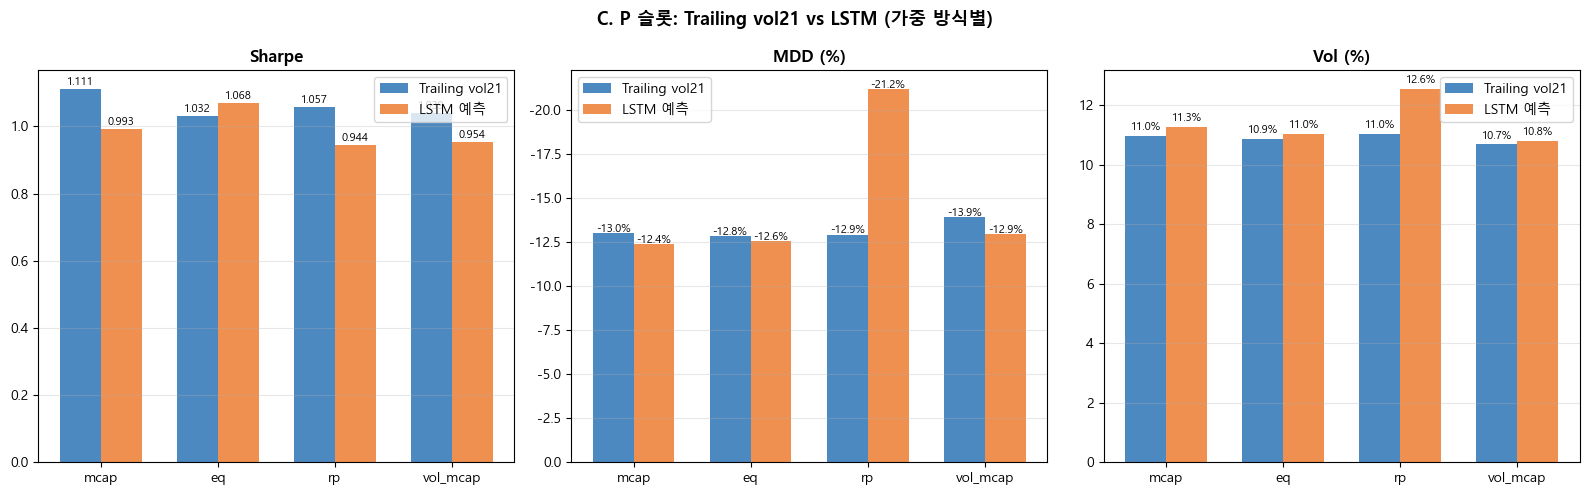

LSTM 효과 (Sharpe 차이, LSTM - Trailing):
  mcap      : -0.118
  eq        : +0.036
  rp        : -0.113
  vol_mcap  : -0.085


In [61]:
weights      = ['mcap', 'eq', 'rp', 'vol_mcap']
trailing_exp = ['baseline', 'p_eq', 'p_rp', 'p_vol_mcap']
lstm_exp     = ['p_lstm_mcap', 'p_lstm_eq', 'p_lstm_rp', 'p_lstm_vol_mcap']

fig, axes = plt.subplots(1, 3, figsize=(16, 5))
x = np.arange(len(weights)); bw = 0.35

for ax, key, title, pct in zip(
    axes,
    ['sharpe', 'mdd', 'vol'],
    ['Sharpe', 'MDD (%)', 'Vol (%)'    ],
    [False,     True,      True        ]
):
    t_vals = [calc(n)[key] * (100 if pct else 1) for n in trailing_exp]
    l_vals = [calc(n)[key] * (100 if pct else 1) for n in lstm_exp]

    b1 = ax.bar(x - bw/2, t_vals, bw, label='Trailing vol21', color='#2E75B6', alpha=0.85)
    b2 = ax.bar(x + bw/2, l_vals, bw, label='LSTM 예측',      color='#ED7D31', alpha=0.85)

    fmt = '{:.1f}%' if pct else '{:.3f}'
    for bars, vals in [(b1, t_vals), (b2, l_vals)]:
        for bar, v in zip(bars, vals):
            ax.text(bar.get_x()+bar.get_width()/2,
                    bar.get_height() + (0.003 if not pct else 0.1),
                    fmt.format(v), ha='center', va='bottom', fontsize=8)

    ax.set_xticks(x); ax.set_xticklabels(weights, fontsize=10)
    ax.set_title(title, fontweight='bold')
    ax.legend(); ax.grid(alpha=0.3, axis='y')
    if key == 'mdd': ax.invert_yaxis()

plt.suptitle('C. P 슬롯: Trailing vol21 vs LSTM (가중 방식별)', fontsize=13, fontweight='bold')
plt.tight_layout()
plt.savefig(OUT_DIR / 'C_trailing_vs_lstm.png', dpi=150, bbox_inches='tight')
plt.show()

print('LSTM 효과 (Sharpe 차이, LSTM - Trailing):')
for w, t, l in zip(weights, trailing_exp, lstm_exp):
    d = calc(l)['sharpe'] - calc(t)['sharpe']
    print(f'  {w:10s}: {d:+.3f}')

## D. Q 슬롯 — fixed vs lambda vs inv_lambda vs raw_lam vs ff3_paper

> Q 조절 방식이 성과에 어떤 영향을 주는가?
> - **fixed**: Q=0.003 고정
> - **lambda**: 강세장 λ↑ → Q↑ (시장 안정 시 뷰 강화)
> - **inv_lambda**: 위기장 λ↓ → Q↑ (위기 시 뷰 강화)
> - **raw_lam**: λ 부호 기반 게이팅 (SPY 하락 시 Q→0)
> - **ff3_paper**: 전월 실현 FF3 팩터로 Q 계산

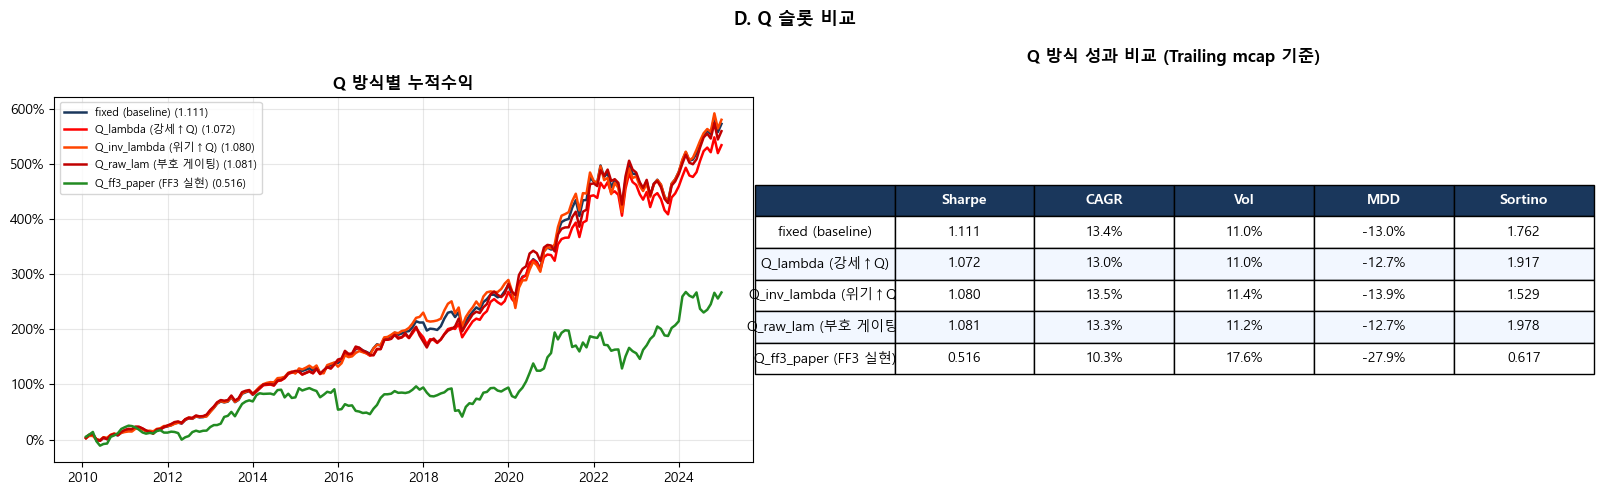

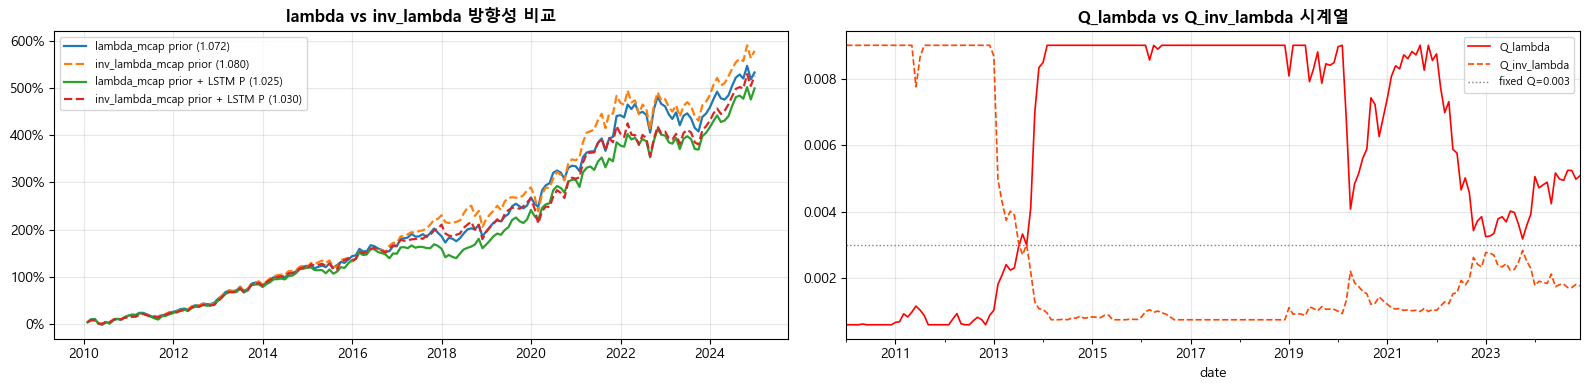

In [62]:
# ── D1. Q 방식 전체 비교 (Trailing P mcap 기준) ────────────────
q_exps   = ['baseline', 'q_lambda', 'q_inv_lambda', 'q_raw_lam', 'q_ff3_paper']
q_labels = ['fixed\n(baseline)', 'Q_lambda\n(강세↑Q)', 'Q_inv_lambda\n(위기↑Q)', 'Q_raw_lam\n(부호 게이팅)', 'Q_ff3_paper\n(FF3 실현)']
colors_q = ['#1A375C', '#FF0000', '#FF4500', '#C00000', '#228B22']

# 존재하는 실험만 필터
q_avail   = [(n, l, c) for n, l, c in zip(q_exps, q_labels, colors_q) if n in loaded]
q_exps    = [x[0] for x in q_avail]
q_labels  = [x[1] for x in q_avail]
colors_q  = [x[2] for x in q_avail]

fig, axes = plt.subplots(1, 2, figsize=(16, 5))

# 누적수익
ax = axes[0]
for name, label, c in zip(q_exps, q_labels, colors_q):
    m = calc(name)
    ax.plot(m['cum'].index, m['cum'].values - 1,
            label=f"{label.replace(chr(10),' ')} ({m['sharpe']:.3f})",
            linewidth=1.8, color=c)
ax.yaxis.set_major_formatter(mtick.PercentFormatter(xmax=1))
ax.set_title('Q 방식별 누적수익', fontweight='bold')
ax.legend(fontsize=8); ax.grid(alpha=0.3)

# 성과 테이블
ax = axes[1]
ax.axis('off')
tdata = [['', 'Sharpe', 'CAGR', 'Vol', 'MDD', 'Sortino']]
for name, label, c in zip(q_exps, q_labels, colors_q):
    m = calc(name)
    tdata.append([label.replace('\n', ' '),
                  f"{m['sharpe']:.3f}",
                  f"{m['cagr']*100:.1f}%",
                  f"{m['vol']*100:.1f}%",
                  f"{m['mdd']*100:.1f}%",
                  f"{m['sortino']:.3f}"])

tbl = ax.table(cellText=tdata[1:], colLabels=tdata[0], loc='center', cellLoc='center')
tbl.auto_set_font_size(False); tbl.set_fontsize(10); tbl.scale(1.2, 2.0)
for (r, c), cell in tbl.get_celld().items():
    if r == 0: cell.set_facecolor('#1A375C'); cell.set_text_props(color='white', fontweight='bold')
    elif r % 2 == 0: cell.set_facecolor('#F2F7FF')
ax.set_title('Q 방식 성과 비교 (Trailing mcap 기준)', fontweight='bold', pad=25)

plt.suptitle('D. Q 슬롯 비교', fontsize=13, fontweight='bold')
plt.tight_layout()
plt.savefig(OUT_DIR / 'D_q_comparison.png', dpi=150, bbox_inches='tight')
plt.show()

# ── D2. lambda vs inv_lambda 방향성 비교 ───────────────────────
fig, axes = plt.subplots(1, 2, figsize=(16, 4))

ax = axes[0]
lambda_pairs = [
    ('q_lambda',     'q_inv_lambda',     'mcap prior'),
    ('q_lambda_p_lstm', 'q_inv_lambda_p_lstm', 'mcap prior + LSTM P'),
]
for base_n, inv_n, lbl in lambda_pairs:
    if base_n in loaded and inv_n in loaded:
        mb = calc(base_n); mi = calc(inv_n)
        ax.plot(mb['cum'].index, mb['cum'].values - 1,
                label=f"lambda_{lbl} ({mb['sharpe']:.3f})", linewidth=1.6)
        ax.plot(mi['cum'].index, mi['cum'].values - 1,
                label=f"inv_lambda_{lbl} ({mi['sharpe']:.3f})", linewidth=1.6, linestyle='--')
ax.yaxis.set_major_formatter(mtick.PercentFormatter(xmax=1))
ax.set_title('lambda vs inv_lambda 방향성 비교', fontweight='bold')
ax.legend(fontsize=8); ax.grid(alpha=0.3)

# Q_lambda 시계열
ax = axes[1]
if 'q_lambda' in loaded and 'meta' in loaded['q_lambda']:
    meta = loaded['q_lambda']['meta']
    if 'Q' in meta.columns:
        meta['Q'].plot(ax=ax, color='#FF0000', linewidth=1.2, label='Q_lambda')
if 'q_inv_lambda' in loaded and 'meta' in loaded['q_inv_lambda']:
    meta_inv = loaded['q_inv_lambda']['meta']
    if 'Q' in meta_inv.columns:
        meta_inv['Q'].plot(ax=ax, color='#FF4500', linewidth=1.2, linestyle='--', label='Q_inv_lambda')
ax.axhline(0.003, color='gray', linestyle=':', linewidth=1, label='fixed Q=0.003')
ax.set_title('Q_lambda vs Q_inv_lambda 시계열', fontweight='bold')
ax.legend(fontsize=8); ax.grid(alpha=0.3)

plt.tight_layout()
plt.savefig(OUT_DIR / 'D_lambda_vs_invlambda.png', dpi=150, bbox_inches='tight')
plt.show()

## E. 최적 조합 — 상위 실험 상세 분석

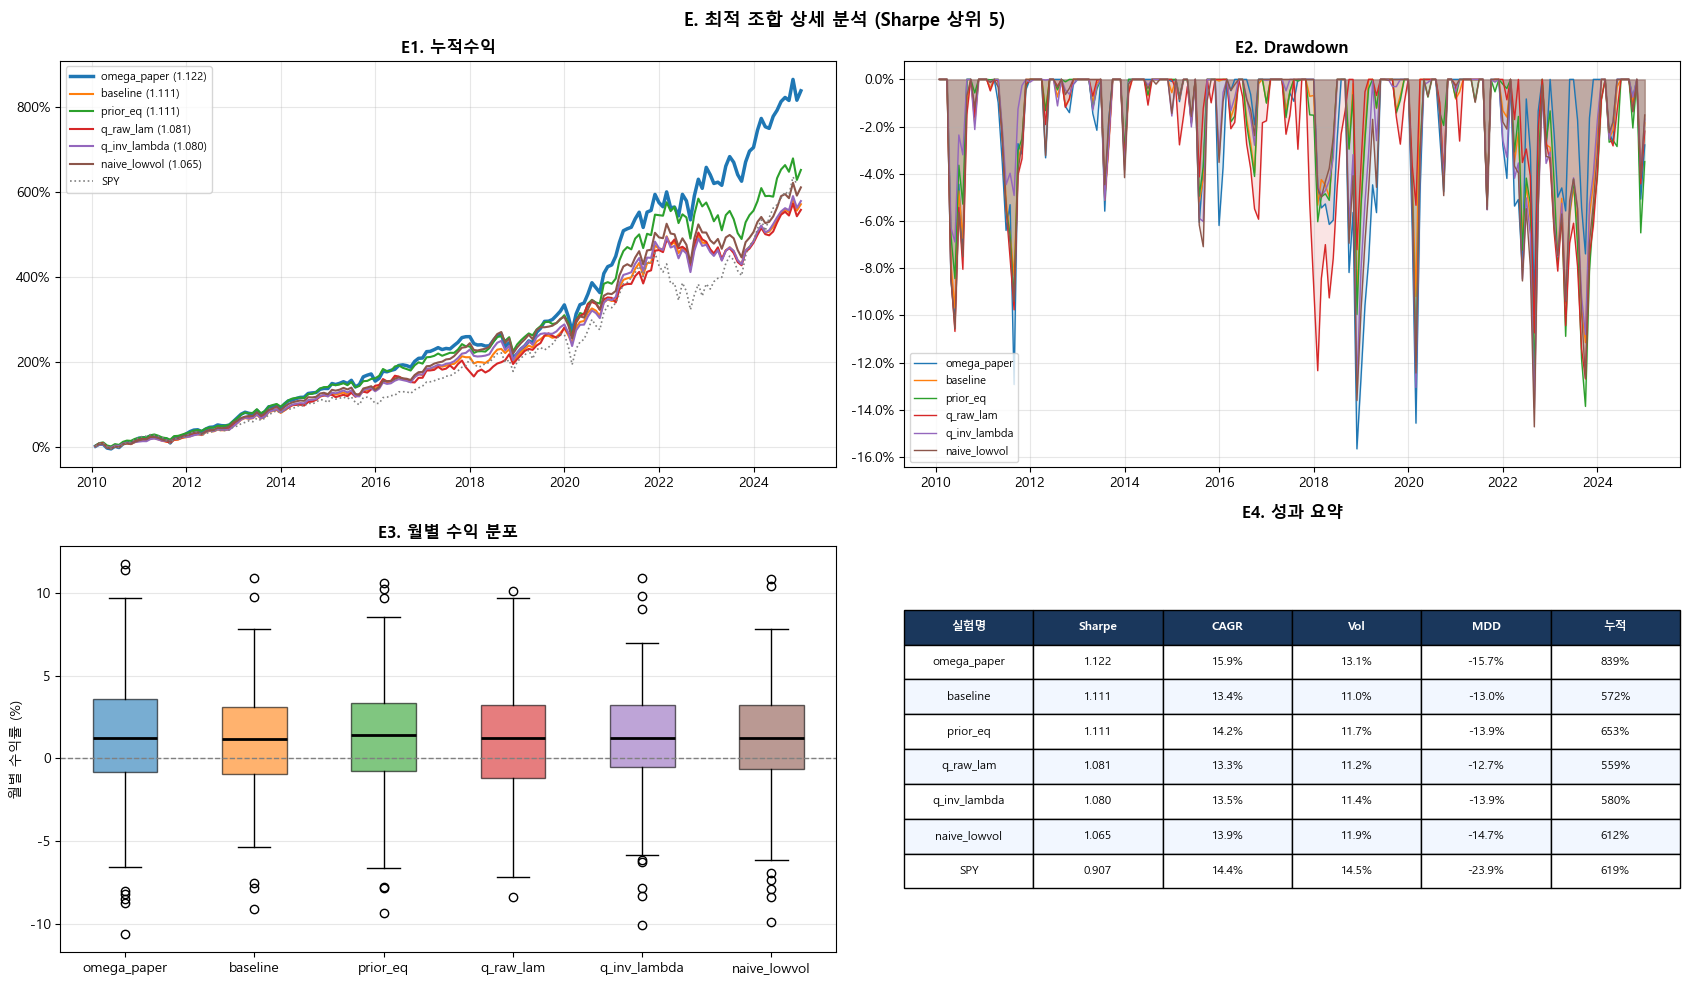


=== 최종 순위 (Sharpe 기준) ===
   1. omega_paper                                    Sharpe 1.122  MDD -15.7%  누적 839%
   2. baseline                                       Sharpe 1.111  MDD -13.0%  누적 572%
   3. prior_eq                                       Sharpe 1.111  MDD -13.9%  누적 653%
   4. q_raw_lam                                      Sharpe 1.081  MDD -12.7%  누적 559%
   5. q_inv_lambda                                   Sharpe 1.080  MDD -13.9%  누적 580%
   6. q_lambda                                       Sharpe 1.072  MDD -12.7%  누적 534%
   7. p_lstm_eq                                      Sharpe 1.068  MDD -12.6%  누적 531%
   8. naive_lowvol                                   Sharpe 1.065  MDD -14.7%  누적 612%
   9. p_rp                                           Sharpe 1.057  MDD -12.9%  누적 520%
  10. prior_eq_q_lambda_p_lstm                       Sharpe 1.040  MDD -12.0%  누적 564%


In [63]:
# Sharpe 상위 5개 선정
rank = sorted(loaded.keys(), key=lambda n: -calc(n)['sharpe'])
top5 = rank[:5]
show = top5 + (['naive_lowvol'] if 'naive_lowvol' not in top5 else [])

colors_e = plt.cm.tab10.colors

fig, axes = plt.subplots(2, 2, figsize=(17, 10))

# E1. 누적수익
ax = axes[0, 0]
for i, name in enumerate(show):
    m = calc(name)
    lw = 2.5 if i == 0 else 1.5
    ax.plot(m['cum'].index, m['cum'].values - 1,
            label=f"{name} ({m['sharpe']:.3f})",
            linewidth=lw, color=colors_e[i])
ax.plot(ms['cum'].index, ms['cum'].values - 1,
        label='SPY', linewidth=1.2, linestyle=':', color='gray')
ax.yaxis.set_major_formatter(mtick.PercentFormatter(xmax=1))
ax.set_title('E1. 누적수익', fontweight='bold'); ax.legend(fontsize=8); ax.grid(alpha=0.3)

# E2. Drawdown
ax = axes[0, 1]
for i, name in enumerate(show):
    m  = calc(name)
    dd = (m['cum'] / m['cum'].cummax()) - 1
    ax.fill_between(dd.index, dd.values, 0, alpha=0.12, color=colors_e[i])
    ax.plot(dd.index, dd.values, linewidth=1.0, color=colors_e[i], label=name)
ax.yaxis.set_major_formatter(mtick.PercentFormatter(xmax=1))
ax.set_title('E2. Drawdown', fontweight='bold'); ax.legend(fontsize=8); ax.grid(alpha=0.3)

# E3. 월별 수익 분포 (박스플롯)
ax = axes[1, 0]
data   = [calc(n)['ret'].values * 100 for n in show]
bp     = ax.boxplot(data, labels=[n.replace('_prior_eq','\nprior_eq') for n in show],
                    patch_artist=True,
                    medianprops=dict(color='black', linewidth=2))
for patch, c in zip(bp['boxes'], colors_e):
    patch.set_facecolor(c); patch.set_alpha(0.6)
ax.axhline(0, color='gray', linestyle='--', linewidth=1)
ax.set_ylabel('월별 수익률 (%)'); ax.set_title('E3. 월별 수익 분포', fontweight='bold')
ax.grid(alpha=0.3, axis='y')

# E4. 성과 요약 테이블
ax = axes[1, 1]
ax.axis('off')
hdr  = ['실험명', 'Sharpe', 'CAGR', 'Vol', 'MDD', '누적']
body = []
for name in show + ['SPY']:
    m = calc(name) if name != 'SPY' else calc_spy()
    body.append([name,
                 f"{m['sharpe']:.3f}",
                 f"{m['cagr']*100:.1f}%",
                 f"{m['vol']*100:.1f}%",
                 f"{m['mdd']*100:.1f}%",
                 f"{m['total']*100:.0f}%"])
tbl = ax.table(cellText=body, colLabels=hdr, loc='center', cellLoc='center')
tbl.auto_set_font_size(False); tbl.set_fontsize(8.5); tbl.scale(1, 1.8)
for (r, c), cell in tbl.get_celld().items():
    if r == 0: cell.set_facecolor('#1A375C'); cell.set_text_props(color='white', fontweight='bold')
    elif r % 2 == 0: cell.set_facecolor('#F2F7FF')
ax.set_title('E4. 성과 요약', fontweight='bold', pad=20)

plt.suptitle('E. 최적 조합 상세 분석 (Sharpe 상위 5)', fontsize=13, fontweight='bold')
plt.tight_layout()
plt.savefig(OUT_DIR / 'E_best_combo.png', dpi=150, bbox_inches='tight')
plt.show()

print('\n=== 최종 순위 (Sharpe 기준) ===')
for i, name in enumerate(rank[:10], 1):
    m = calc(name)
    print(f'  {i:2d}. {name:45s}  Sharpe {m["sharpe"]:.3f}  MDD {m["mdd"]*100:.1f}%  누적 {m["total"]*100:.0f}%')

## F. Trailing vs LSTM — 왜 성과 차이가 나는가?

> 종목 구성과 섹터 비중으로 전략 차이를 확인합니다.

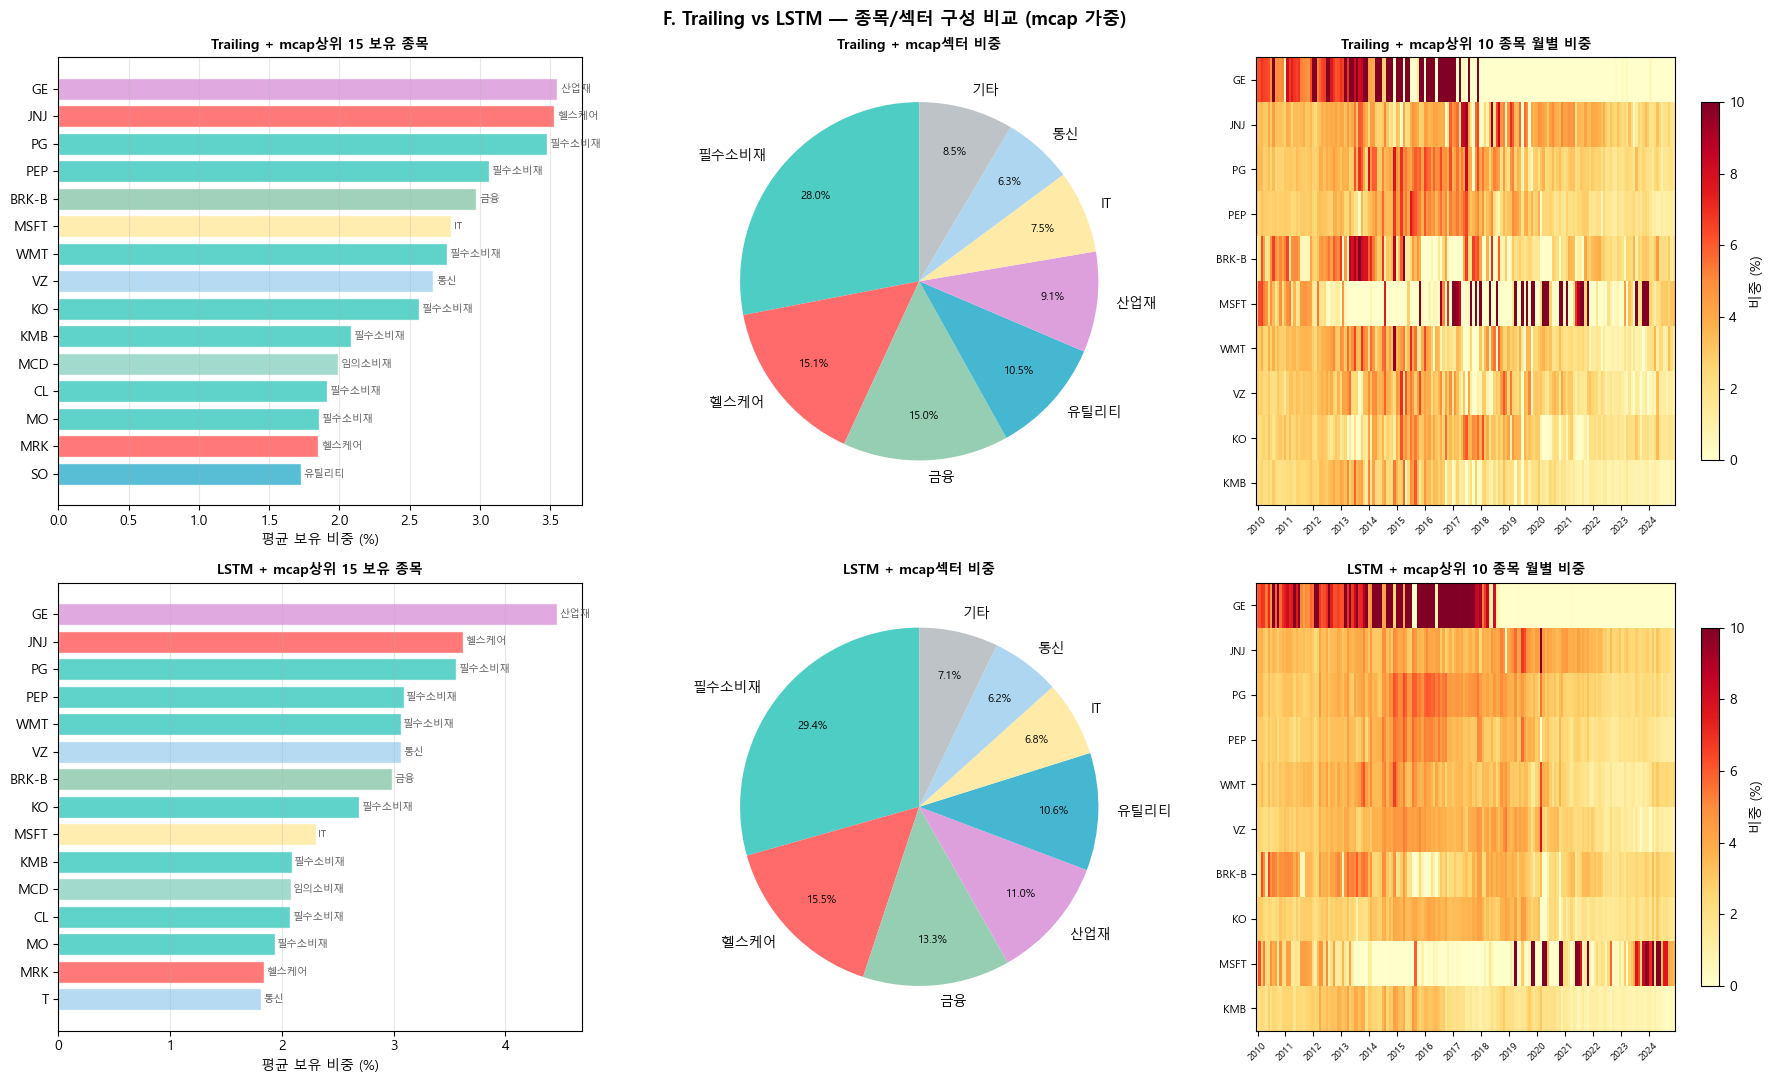

=== 섹터 비중 비교 ===
섹터              Trailing        LSTM        차이
---------------------------------------------
필수소비재              28.0%       29.4%     +1.4%
헬스케어               15.1%       15.5%     +0.4%
금융                 15.0%       13.3%     -1.7%
유틸리티               10.5%       10.6%     +0.1%
산업재                 9.1%       11.0%     +1.9%
IT                  7.5%        6.8%     -0.7%
통신                  6.3%        6.2%     -0.1%
임의소비재               3.9%        3.5%     -0.4%
부동산                 2.2%        1.8%     -0.4%
에너지                 1.7%        1.3%     -0.4%
소재                  0.5%        0.4%     -0.1%
기타                  0.2%        0.1%     -0.1%


In [64]:
# ── 섹터 데이터 로드 & 정규화 ──────────────────────────────
panel_sector = pd.read_csv(
    Path.cwd() / "data" / "monthly_panel.csv",
    usecols=["date","ticker","gics_sector"], parse_dates=["date"]
)

SECTOR_MAP = {
    "Information Technology": "IT",         "Technology"            : "IT",
    "Health Care"           : "헬스케어",    "Healthcare"            : "헬스케어",
    "Consumer Staples"      : "필수소비재",  "Consumer Defensive"    : "필수소비재",
    "Utilities"             : "유틸리티",
    "Financials"            : "금융",        "Financial Services"    : "금융",
    "Industrials"           : "산업재",
    "Consumer Discretionary": "임의소비재",  "Consumer Cyclical"     : "임의소비재",
    "Energy"                : "에너지",
    "Communication Services": "통신",
    "Materials"             : "소재",        "Basic Materials"       : "소재",
    "Real Estate"           : "부동산",
}
panel_sector["sector"] = panel_sector["gics_sector"].map(lambda x: SECTOR_MAP.get(x, "기타"))
ticker_sector = panel_sector.groupby("ticker")["sector"].agg(lambda x: x.mode().iloc[0])

# ── 비교 두 전략 ─────────────────────────────────────────────
compare_pair = [("baseline", "Trailing + mcap"), ("p_lstm_mcap", "LSTM + mcap")]

SCOL = {
    "헬스케어":"#FF6B6B", "필수소비재":"#4ECDC4", "유틸리티":"#45B7D1",
    "금융":"#96CEB4",     "IT":"#FFEAA7",         "산업재":"#DDA0DD",
    "임의소비재":"#98D8C8","에너지":"#F7DC6F",     "기타":"#BDC3C7",
    "통신":"#AED6F1",     "소재":"#FAD7A0",        "부동산":"#A9CCE3",
}

fig, axes = plt.subplots(2, 3, figsize=(18, 11))

for row_idx, (name, label) in enumerate(compare_pair):
    w_df = loaded[name]["weights"]

    # F1. 상위 15 보유 종목
    ax = axes[row_idx, 0]
    avg_w = w_df.mean().sort_values(ascending=False).head(15)
    secs  = [ticker_sector.get(t, "기타") for t in avg_w.index]
    bars  = ax.barh(avg_w.index[::-1], avg_w.values[::-1]*100,
                    color=[SCOL.get(s,"#BDC3C7") for s in secs[::-1]],
                    alpha=0.9, edgecolor="white")
    for bar, s in zip(bars, secs[::-1]):
        ax.text(bar.get_width()+0.02, bar.get_y()+bar.get_height()/2,
                s, va="center", fontsize=7.5, color="#555")
    ax.set_xlabel("평균 보유 비중 (%)")
    ax.set_title(f"{label}상위 15 보유 종목", fontweight="bold", fontsize=10)
    ax.grid(alpha=0.3, axis="x")

    # F2. 섹터 비중 파이차트
    ax = axes[row_idx, 1]
    sw = {}
    for ticker in w_df.columns:
        sec = ticker_sector.get(ticker, "기타")
        sw[sec] = sw.get(sec, 0) + w_df[ticker].mean()
    sw_s  = pd.Series(sw).sort_values(ascending=False)
    total = sw_s.sum()
    major = sw_s[sw_s/total >= 0.04].copy()
    other = sw_s[sw_s/total < 0.04].sum()
    if other > 0:
        major["기타"] = major.get("기타", 0) + other
    _, texts, autotexts = ax.pie(
        major.values, labels=major.index,
        autopct="%1.1f%%", colors=[SCOL.get(s,"#BDC3C7") for s in major.index],
        startangle=90, pctdistance=0.75
    )
    for t in autotexts: t.set_fontsize(8)
    ax.set_title(f"{label}섹터 비중", fontweight="bold", fontsize=10)

    # F3. 상위 10 종목 월별 비중 히트맵
    ax = axes[row_idx, 2]
    top10     = w_df.mean().sort_values(ascending=False).head(10).index
    heat_data = w_df[top10].T * 100
    im = ax.imshow(heat_data.values, aspect="auto", cmap="YlOrRd", interpolation="nearest")
    ax.set_yticks(range(len(top10))); ax.set_yticklabels(top10, fontsize=8)
    years    = [d.year for d in heat_data.columns]
    yr_ticks = [i for i in range(len(years)) if i == 0 or years[i] != years[i-1]]
    ax.set_xticks(yr_ticks)
    ax.set_xticklabels([years[i] for i in yr_ticks], rotation=45, fontsize=7)
    plt.colorbar(im, ax=ax, shrink=0.8, label="비중 (%)")
    ax.set_title(f"{label}상위 10 종목 월별 비중", fontweight="bold", fontsize=10)

plt.suptitle("F. Trailing vs LSTM — 종목/섹터 구성 비교 (mcap 가중)",
             fontsize=13, fontweight="bold")
plt.tight_layout()
plt.savefig(OUT_DIR / "F_holdings_comparison.png", dpi=150, bbox_inches="tight")
plt.show()

# ── 섹터 비중 텍스트 요약 ────────────────────────────────────
def get_sector_w(name):
    w_df = loaded[name]["weights"]
    sw = {}
    for ticker in w_df.columns:
        sec = ticker_sector.get(ticker, "기타")
        sw[sec] = sw.get(sec, 0) + w_df[ticker].mean()
    total = sum(sw.values())
    return pd.Series({k: v/total for k, v in sw.items()})

sw_trail = get_sector_w("baseline")
sw_lstm  = get_sector_w("p_lstm_mcap")
all_secs = sorted(set(sw_trail.index)|set(sw_lstm.index), key=lambda s: -sw_trail.get(s,0))

print("=== 섹터 비중 비교 ===")
print(f"{'섹터':12s}  {'Trailing':>10s}  {'LSTM':>10s}  {'차이':>8s}")
print("-"*45)
for sec in all_secs:
    t = sw_trail.get(sec, 0); l = sw_lstm.get(sec, 0)
    print(f"{sec:12s}  {t:>10.1%}  {l:>10.1%}  {l-t:>+8.1%}")


## G. Omega 슬롯 — he_litterman vs 논문 방식 (ff3_paper)

> Ω 계산 방식이 성과에 어떤 영향을 주는가?
> - **he_litterman** (기본): Ω = τ·P·Σ·Pᵀ
> - **ff3_paper** (논문): Ω_t = (Q_hat_{t-1} − Q_actual_{t-1})²  (전월 예측오차²)
>
> | 실험명 | Q 방식 | Ω 방식 | 설명 |
> |---|---|---|---|
> | `baseline` | fixed | he_litterman | 기준 |
> | `omega_paper` | fixed | ff3_paper | Ω만 논문 방식 |
> | `omega_paper_p_lstm` | fixed | ff3_paper | Ω 논문 + LSTM P |
> | `q_ff3_paper` | ff3_paper | he_litterman | Q만 논문 방식 |
> | `q_ff3_paper_omega_paper` | ff3_paper | ff3_paper | Q+Ω 완전 논문 구현 |

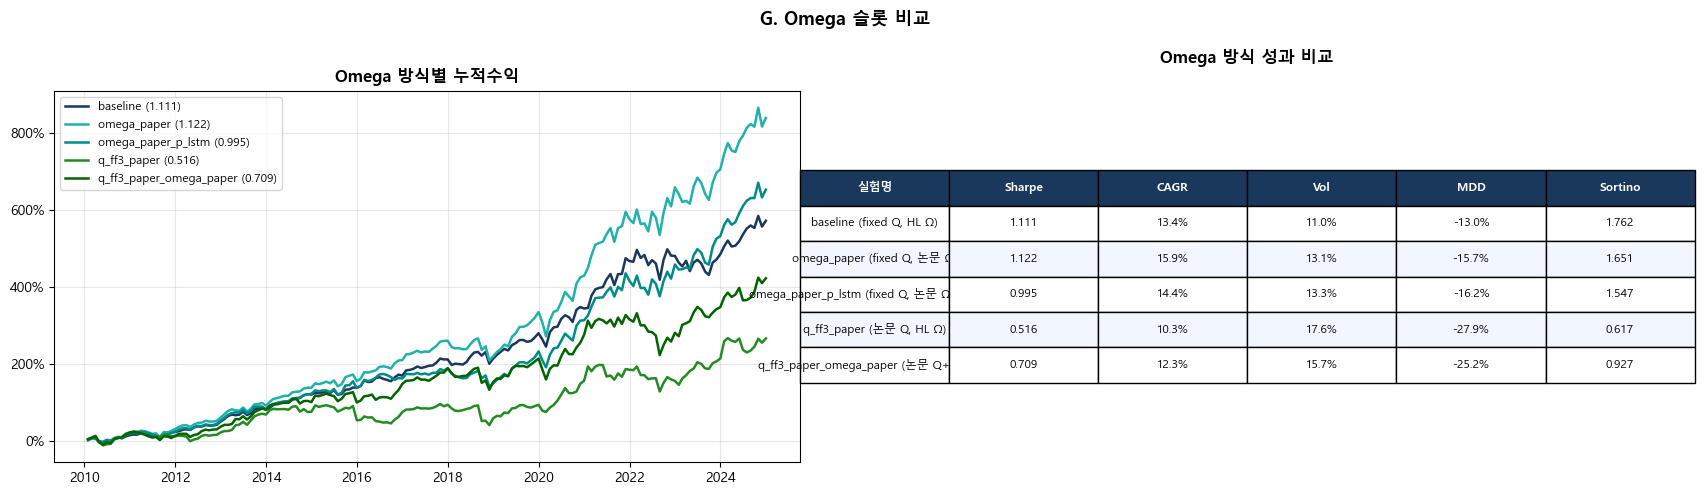

=== Omega 방식별 성과 요약 ===
실험명                                        Sharpe     CAGR      Vol      MDD
----------------------------------------------------------------------
baseline                                    1.111    13.4%    11.0%   -13.0%
omega_paper                                 1.122    15.9%    13.1%   -15.7%
omega_paper_p_lstm                          0.995    14.4%    13.3%   -16.2%
q_ff3_paper                                 0.516    10.3%    17.6%   -27.9%
q_ff3_paper_omega_paper                     0.709    12.3%    15.7%   -25.2%

=== baseline 대비 Sharpe 변화 ===
  omega_paper                           : +0.011
  omega_paper_p_lstm                    : -0.116
  q_ff3_paper                           : -0.595
  q_ff3_paper_omega_paper               : -0.403


In [65]:
# ── G1. Omega 방식별 성과 비교 ─────────────────────────────────
omega_exps   = ['baseline', 'omega_paper', 'omega_paper_p_lstm', 'q_ff3_paper', 'q_ff3_paper_omega_paper']
omega_labels = ['baseline\n(fixed Q, HL Ω)', 'omega_paper\n(fixed Q, 논문 Ω)', 'omega_paper_p_lstm\n(fixed Q, 논문 Ω, LSTM P)',
                'q_ff3_paper\n(논문 Q, HL Ω)', 'q_ff3_paper_omega_paper\n(논문 Q+Ω 완전)']
colors_om    = ['#1A375C', '#20B2AA', '#008B8B', '#228B22', '#006400']

# 존재하는 실험만
om_avail      = [(n, l, c) for n, l, c in zip(omega_exps, omega_labels, colors_om) if n in loaded]
omega_exps    = [x[0] for x in om_avail]
omega_labels  = [x[1] for x in om_avail]
colors_om     = [x[2] for x in om_avail]

fig, axes = plt.subplots(1, 2, figsize=(17, 5))

# 누적수익
ax = axes[0]
for name, label, c in zip(omega_exps, omega_labels, colors_om):
    m = calc(name)
    ax.plot(m['cum'].index, m['cum'].values - 1,
            label=f"{label.split(chr(10))[0]} ({m['sharpe']:.3f})",
            linewidth=1.8, color=c)
ax.yaxis.set_major_formatter(mtick.PercentFormatter(xmax=1))
ax.set_title('Omega 방식별 누적수익', fontweight='bold')
ax.legend(fontsize=8.5); ax.grid(alpha=0.3)

# 성과 테이블
ax = axes[1]
ax.axis('off')
tdata = [['실험명', 'Sharpe', 'CAGR', 'Vol', 'MDD', 'Sortino']]
for name, label, c in zip(omega_exps, omega_labels, colors_om):
    m = calc(name)
    tdata.append([label.replace('\n', ' '),
                  f"{m['sharpe']:.3f}",
                  f"{m['cagr']*100:.1f}%",
                  f"{m['vol']*100:.1f}%",
                  f"{m['mdd']*100:.1f}%",
                  f"{m['sortino']:.3f}"])

tbl = ax.table(cellText=tdata[1:], colLabels=tdata[0], loc='center', cellLoc='center')
tbl.auto_set_font_size(False); tbl.set_fontsize(8.5); tbl.scale(1.2, 2.2)
for (r, c), cell in tbl.get_celld().items():
    if r == 0: cell.set_facecolor('#1A375C'); cell.set_text_props(color='white', fontweight='bold')
    elif r % 2 == 0: cell.set_facecolor('#F2F7FF')
ax.set_title('Omega 방식 성과 비교', fontweight='bold', pad=20)

plt.suptitle('G. Omega 슬롯 비교', fontsize=13, fontweight='bold')
plt.tight_layout()
plt.savefig(OUT_DIR / 'G_omega_comparison.png', dpi=150, bbox_inches='tight')
plt.show()

# ── G2. Omega 방식 요약 ─────────────────────────────────────────
print('=== Omega 방식별 성과 요약 ===')
print(f"{'실험명':40s}  {'Sharpe':>7s}  {'CAGR':>7s}  {'Vol':>7s}  {'MDD':>7s}")
print('-' * 70)
for name, label in zip(omega_exps, omega_labels):
    m = calc(name)
    tag = label.split('\n')[0]
    print(f"{tag:40s}  {m['sharpe']:>7.3f}  {m['cagr']*100:>6.1f}%  {m['vol']*100:>6.1f}%  {m['mdd']*100:>6.1f}%")

# baseline 대비 증감
print('\n=== baseline 대비 Sharpe 변화 ===')
base_sh = calc('baseline')['sharpe']
for name, label in zip(omega_exps[1:], omega_labels[1:]):
    tag = label.split('\n')[0]
    d = calc(name)['sharpe'] - base_sh
    print(f"  {tag:38s}: {d:+.3f}")

## H. 서브기간 강건성 분석

> **질문: baseline이 전 구간에서 일관되게 좋은가, 아니면 특정 시기에만 좋은가?**
>
> | 기간 | 시장 환경 |
> |---|---|
> | 2010–2014 | 금융위기 이후 회복, 저변동 강세장 |
> | 2015–2019 | 변동성 확대(2015 차이나 쇼크, 2018 금리 충격), 중간 강세 |
> | 2020–2024 | 코로나 급락·반등, 인플레이션, 금리 급등·안정화 |

In [66]:
# ── H1. 서브기간 정의 및 성과 계산 ────────────────────────────
PERIODS = {
    '2010–2014': ('2010-01-01', '2014-12-31'),
    '2015–2019': ('2015-01-01', '2019-12-31'),
    '2020–2024': ('2020-01-01', '2024-12-31'),
}

def calc_sub(name, start, end):
    r    = loaded[name]['ret'].dropna()
    r    = r[(r.index >= start) & (r.index <= end)]
    if len(r) < 6:
        return None
    rf_a = rf.reindex(r.index).fillna(0)
    exc  = r - rf_a
    ann  = exc.mean() * 12
    vol  = r.std() * np.sqrt(12)
    sh   = ann / vol if vol > 0 else np.nan
    cum  = (1 + r).cumprod()
    mdd  = ((cum / cum.cummax()) - 1).min()
    dsd  = r[r < 0].std() * np.sqrt(12)
    sor  = ann / dsd if dsd > 0 else np.nan
    cagr = r.mean() * 12
    return dict(sharpe=sh, cagr=cagr, vol=vol, mdd=mdd, sortino=sor)

def calc_spy_sub(start, end):
    r    = spy_ret[(spy_ret.index >= start) & (spy_ret.index <= end)]
    rf_a = rf.reindex(r.index).fillna(0)
    exc  = r - rf_a
    ann  = exc.mean() * 12
    vol  = r.std() * np.sqrt(12)
    sh   = ann / vol
    return dict(sharpe=sh, cagr=r.mean()*12, vol=vol)

# ── 전체 실험 × 전체 서브기간 Sharpe 매트릭스 ─────────────────
all_exps = sorted(loaded.keys())
sharpe_mat = {}
for period, (s, e) in PERIODS.items():
    row = {}
    for name in all_exps:
        m = calc_sub(name, s, e)
        row[name] = m['sharpe'] if m else np.nan
    sharpe_mat[period] = row

df_sub = pd.DataFrame(sharpe_mat).T   # periods × experiments

print('=== 서브기간별 Sharpe 매트릭스 ===')
print(df_sub.round(3).to_string())
print()
print('=== SPY 서브기간 Sharpe ===')
for period, (s, e) in PERIODS.items():
    ms_sub = calc_spy_sub(s, e)
    print(f"  {period}: {ms_sub['sharpe']:.3f}")

=== 서브기간별 Sharpe 매트릭스 ===
           baseline  capm_no_bl  hrp_lstm  hrp_trailing  naive_lowvol  omega_paper  omega_paper_p_lstm   p_eq  p_lstm_eq  p_lstm_mcap  p_lstm_rp  p_lstm_vol_mcap   p_rp  p_vol_mcap  prior_eq  prior_eq_p_lstm_eq  prior_eq_p_lstm_mcap  prior_eq_p_lstm_rp  prior_eq_p_lstm_rp_q_lambda  prior_eq_p_lstm_vol_mcap  prior_eq_q_inv_lambda_p_lstm  prior_eq_q_lambda_p_lstm  q_ff3_paper  q_ff3_paper_omega_paper  q_inv_lambda  q_inv_lambda_p_lstm  q_lambda  q_lambda_p_lstm  q_raw_lam
2010–2014     1.639       1.132     1.929         1.666         1.624        1.436               1.336  1.682      1.746        1.602      1.092            1.700  1.609       1.650     1.878               1.911                 1.807               1.209                        1.220                     1.856                         1.967                     1.701        0.784                    0.973         1.786                1.782     1.585            1.543      1.587
2015–2019     1.132     

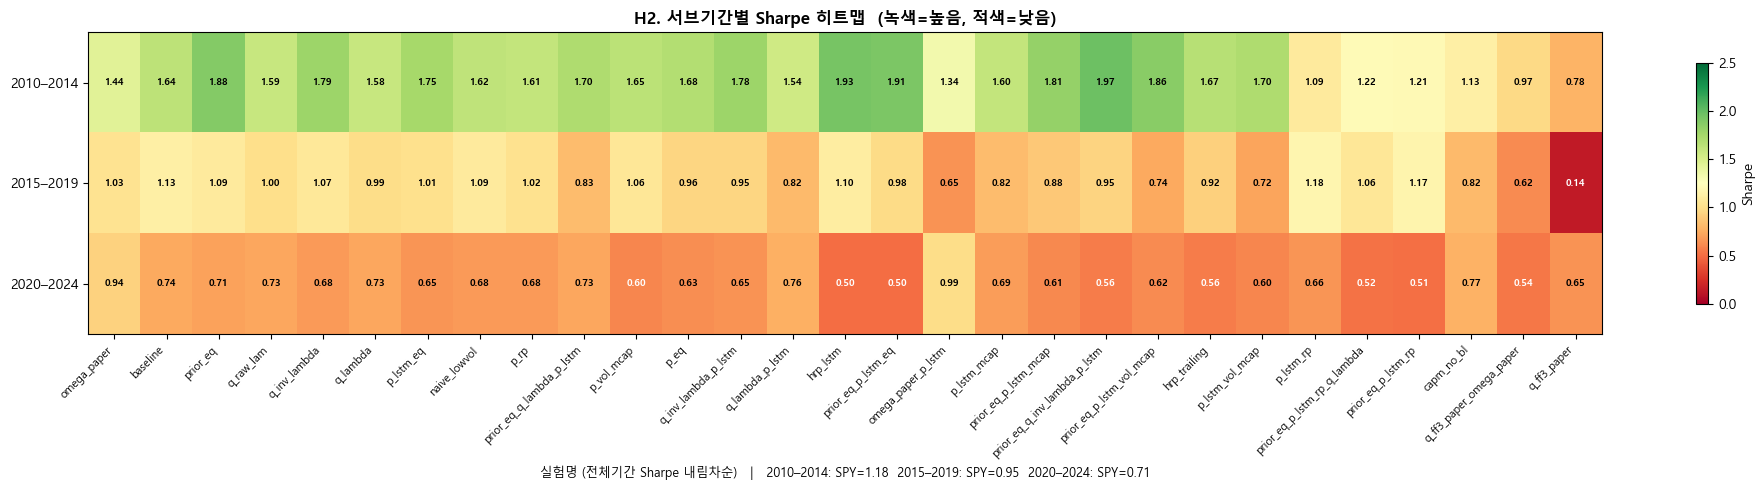

In [67]:
# ── H2. Sharpe 히트맵 (전체 실험 × 서브기간) ───────────────────
fig, ax = plt.subplots(figsize=(20, 5))

# 전체기간 Sharpe 기준으로 실험 정렬
full_sharpe = {n: calc(n)['sharpe'] for n in all_exps}
exp_order   = sorted(all_exps, key=lambda n: -full_sharpe[n])
heat_data   = df_sub[exp_order]

spy_shs = {p: calc_spy_sub(s, e)['sharpe'] for p, (s, e) in PERIODS.items()}

im = ax.imshow(heat_data.values, aspect='auto', cmap='RdYlGn',
               vmin=0.0, vmax=2.5, interpolation='nearest')

ax.set_xticks(range(len(exp_order)))
ax.set_xticklabels(exp_order, rotation=45, ha='right', fontsize=8)
ax.set_yticks(range(len(PERIODS)))
ax.set_yticklabels(list(PERIODS.keys()), fontsize=10)

# 셀 값 표시
for i, period in enumerate(PERIODS.keys()):
    for j, exp in enumerate(exp_order):
        v = heat_data.loc[period, exp]
        txt_color = 'white' if v < 0.6 or v > 2.0 else 'black'
        if not np.isnan(v):
            ax.text(j, i, f'{v:.2f}', ha='center', va='center',
                    fontsize=7, color=txt_color, fontweight='bold')

# SPY 기준선 표시
spy_text = '  '.join([f"{p}: SPY={v:.2f}" for p, v in spy_shs.items()])
ax.set_xlabel(f'실험명 (전체기간 Sharpe 내림차순)   |   {spy_text}', fontsize=9)
ax.set_title('H2. 서브기간별 Sharpe 히트맵  (녹색=높음, 적색=낮음)', fontweight='bold', fontsize=12)
plt.colorbar(im, ax=ax, label='Sharpe', shrink=0.8)
plt.tight_layout()
plt.savefig(OUT_DIR / 'H_subperiod_heatmap.png', dpi=150, bbox_inches='tight')
plt.show()

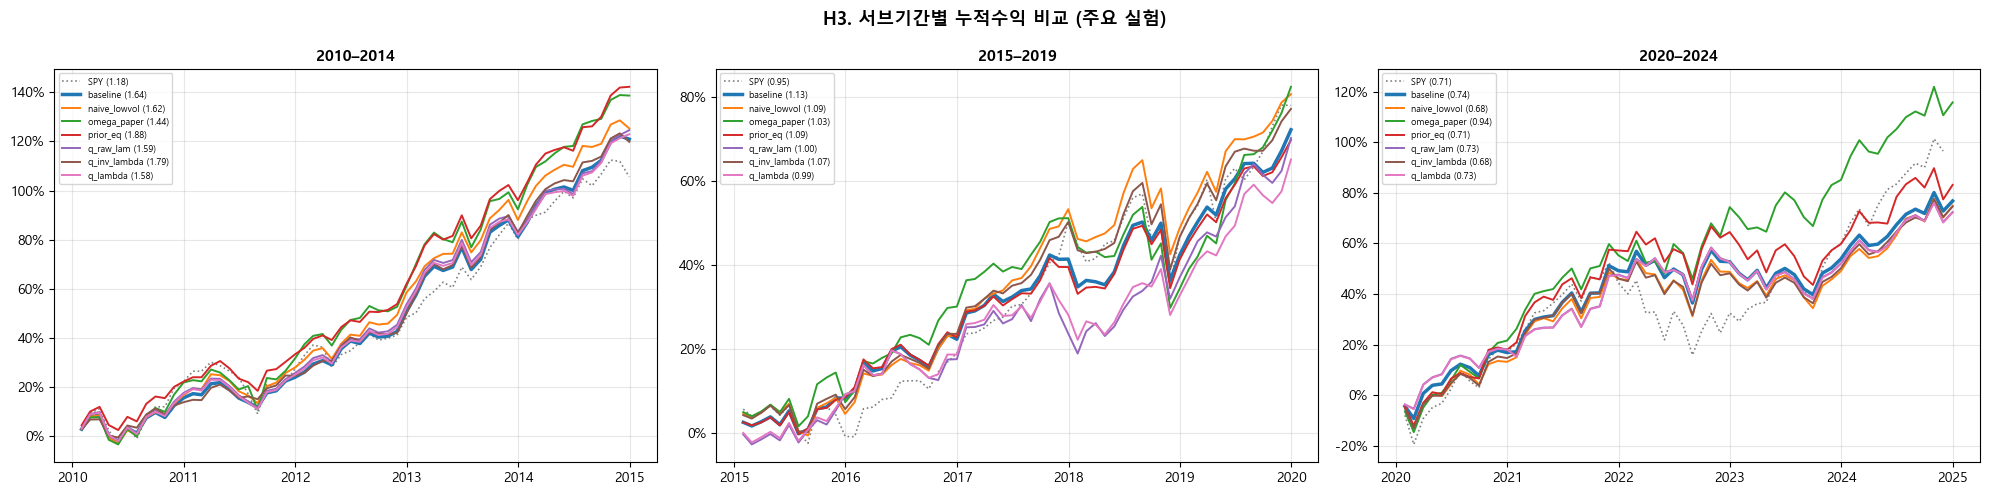

=== 서브기간별 Sharpe 상위 5 ===

  [2010–2014]  SPY=1.178
    1. prior_eq_q_inv_lambda_p_lstm                   Sharpe 1.967
    2. hrp_lstm                                       Sharpe 1.929
    3. prior_eq_p_lstm_eq                             Sharpe 1.911
    4. prior_eq                                       Sharpe 1.878
    5. prior_eq_p_lstm_vol_mcap                       Sharpe 1.856

  [2015–2019]  SPY=0.951
    1. p_lstm_rp                                      Sharpe 1.181
    2. prior_eq_p_lstm_rp                             Sharpe 1.170
    3. baseline                                       Sharpe 1.132
    4. hrp_lstm                                       Sharpe 1.104
    5. prior_eq                                       Sharpe 1.091

  [2020–2024]  SPY=0.714
    1. omega_paper_p_lstm                             Sharpe 0.989
    2. omega_paper                                    Sharpe 0.935
    3. capm_no_bl                                     Sharpe 0.772
    4. q_lambda_p_lstm   

In [68]:
# ── H3. 주요 실험 서브기간 누적수익 비교 ──────────────────────
# 전체기간 상위 6 + naive_lowvol + baseline 비교
top6 = sorted(all_exps, key=lambda n: -full_sharpe[n])[:6]
focus = list(dict.fromkeys(['baseline', 'naive_lowvol'] + top6))  # 중복 제거

period_list = list(PERIODS.items())
fig, axes = plt.subplots(1, 3, figsize=(20, 5), sharey=False)
colors_h = plt.cm.tab10.colors

for ax, (period, (s, e)) in zip(axes, period_list):
    spy_sub = spy_ret[(spy_ret.index >= s) & (spy_ret.index <= e)]
    spy_cum = (1 + spy_sub).cumprod()
    ax.plot(spy_cum.index, spy_cum.values - 1, color='gray', linestyle=':',
            linewidth=1.2, label=f"SPY ({calc_spy_sub(s,e)['sharpe']:.2f})")

    for i, name in enumerate(focus):
        r_sub = loaded[name]['ret'].dropna()
        r_sub = r_sub[(r_sub.index >= s) & (r_sub.index <= e)]
        if len(r_sub) < 3:
            continue
        cum_sub = (1 + r_sub).cumprod()
        m_sub   = calc_sub(name, s, e)
        lw = 2.5 if name == 'baseline' else 1.4
        ax.plot(cum_sub.index, cum_sub.values - 1,
                label=f"{name} ({m_sub['sharpe']:.2f})",
                linewidth=lw, color=colors_h[i % 10])

    ax.yaxis.set_major_formatter(mtick.PercentFormatter(xmax=1))
    ax.set_title(f'{period}', fontweight='bold', fontsize=11)
    ax.legend(fontsize=6.5, loc='upper left'); ax.grid(alpha=0.3)

plt.suptitle('H3. 서브기간별 누적수익 비교 (주요 실험)', fontsize=13, fontweight='bold')
plt.tight_layout()
plt.savefig(OUT_DIR / 'H_subperiod_cumret.png', dpi=150, bbox_inches='tight')
plt.show()

# ── H4. 서브기간 순위 안정성 요약 ─────────────────────────────
print('=== 서브기간별 Sharpe 상위 5 ===')
for period, (s, e) in PERIODS.items():
    sub_rank = sorted(all_exps, key=lambda n: -(calc_sub(n, s, e) or {}).get('sharpe', -999))
    spy_sh   = calc_spy_sub(s, e)['sharpe']
    print(f'\n  [{period}]  SPY={spy_sh:.3f}')
    for rank_i, name in enumerate(sub_rank[:5], 1):
        m = calc_sub(name, s, e)
        print(f'    {rank_i}. {name:45s}  Sharpe {m["sharpe"]:.3f}')

# ── H5. baseline 서브기간 순위 ─────────────────────────────────
print('\n=== baseline 서브기간 순위 ===')
for period, (s, e) in PERIODS.items():
    sub_rank = sorted(all_exps, key=lambda n: -(calc_sub(n, s, e) or {}).get('sharpe', -999))
    rank_bl  = sub_rank.index('baseline') + 1
    m_bl     = calc_sub('baseline', s, e)
    print(f"  {period}: {rank_bl}위 / {len(all_exps)}개  (Sharpe {m_bl['sharpe']:.3f})")

## I. Turnover & 거래비용 분석

> **이미 모든 성과 지표(Sharpe, CAGR 등)는 TC 차감 후 net return 기준입니다.**
> 이 섹션은 전략별 turnover 자체를 시각화합니다.
>
> - **Turnover**: 월별 `|w_new - w_prev|` 합계 (0~2, 완전교체=2.0)
> - **TC 비용**: turnover × 0.001 (10bp 편도)
> - **연간 TC 비용**: 월평균 TC × 12

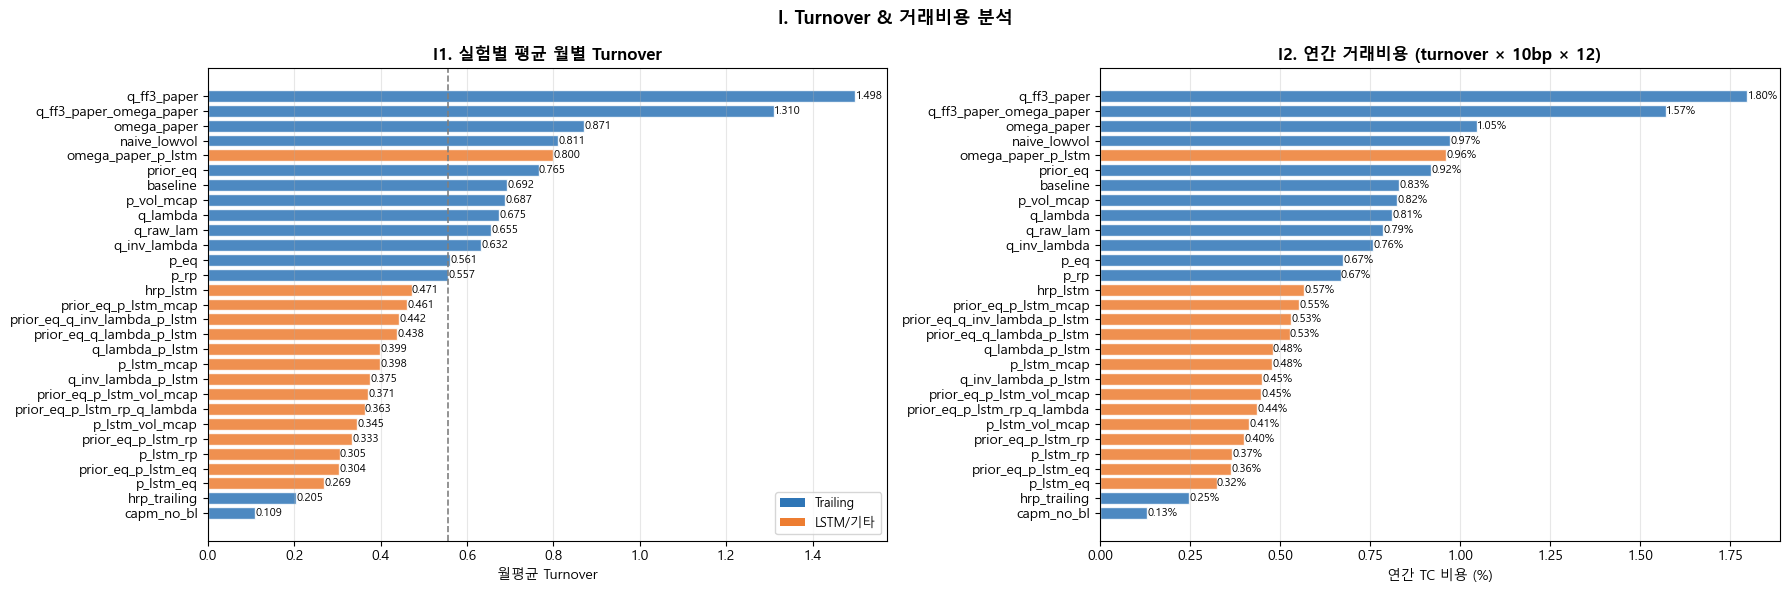

=== Turnover 요약 ===
실험명                                          월평균 TO     연간 TC     TC 드래그
------------------------------------------------------------------------
[T] q_ff3_paper                               1.4982    1.798%      1.80%
[T] q_ff3_paper_omega_paper                   1.3097    1.572%      1.57%
[T] omega_paper                               0.8714    1.046%      1.05%
[T] naive_lowvol                              0.8108    0.973%      0.97%
[L] omega_paper_p_lstm                        0.8002    0.960%      0.96%
[T] prior_eq                                  0.7655    0.919%      0.92%
[T] baseline                                  0.6925    0.831%      0.83%
[T] p_vol_mcap                                0.6873    0.825%      0.82%
[T] q_lambda                                  0.6751    0.810%      0.81%
[T] q_raw_lam                                 0.6547    0.786%      0.79%
[T] q_inv_lambda                              0.6324    0.759%      0.76%
[T] p_eq            

In [69]:
# ── I1. 실험별 평균 Turnover 및 연간 TC 비용 ───────────────────
TC_RATE = 0.001  # 10bp

to_rows = []
for name in sorted(loaded.keys()):
    comp = loaded[name].get('comp', pd.DataFrame())
    if comp.empty or 'turnover' not in comp.columns:
        continue
    to_mean  = comp['turnover'].mean()
    tc_ann   = to_mean * TC_RATE * 12   # 연간 TC 비용 (%)
    gross_r  = loaded[name].get('gross_ret', pd.Series(dtype=float))
    net_r    = loaded[name]['ret']
    tc_drag  = (gross_r.mean() - net_r.mean()) * 12 if len(gross_r) > 0 else np.nan
    to_rows.append(dict(name=name, turnover=to_mean, tc_annual=tc_ann, tc_drag=tc_drag))

df_to = pd.DataFrame(to_rows).set_index('name').sort_values('turnover', ascending=False)

# 그룹 분류 (Trailing vs LSTM)
trailing_names = {'baseline', 'p_eq', 'p_rp', 'p_vol_mcap', 'prior_eq',
                  'q_lambda', 'q_raw_lam', 'q_inv_lambda', 'naive_lowvol',
                  'capm_no_bl', 'hrp_trailing', 'omega_paper',
                  'q_ff3_paper', 'q_ff3_paper_omega_paper'}
bar_colors = ['#2E75B6' if n in trailing_names else '#ED7D31'
              for n in df_to.index]

fig, axes = plt.subplots(1, 2, figsize=(18, 6))

# I1-a. 평균 월별 turnover
ax = axes[0]
bars = ax.barh(df_to.index[::-1], df_to['turnover'][::-1],
               color=bar_colors[::-1], alpha=0.85, edgecolor='white')
ax.axvline(df_to['turnover'].mean(), color='gray', linestyle='--', linewidth=1.2,
           label=f"전체 평균 ({df_to['turnover'].mean():.3f})")
for bar, v in zip(bars, df_to['turnover'][::-1]):
    ax.text(v + 0.001, bar.get_y() + bar.get_height()/2,
            f'{v:.3f}', va='center', fontsize=8)
ax.set_xlabel('월평균 Turnover')
ax.set_title('I1. 실험별 평균 월별 Turnover', fontweight='bold')
ax.legend(fontsize=9)
from matplotlib.patches import Patch
legend_elements = [Patch(facecolor='#2E75B6', label='Trailing'),
                   Patch(facecolor='#ED7D31', label='LSTM/기타')]
ax.legend(handles=legend_elements, fontsize=9)
ax.grid(alpha=0.3, axis='x')

# I1-b. 연간 TC 비용
ax = axes[1]
bars = ax.barh(df_to.index[::-1], df_to['tc_annual'][::-1] * 100,
               color=bar_colors[::-1], alpha=0.85, edgecolor='white')
for bar, v in zip(bars, df_to['tc_annual'][::-1] * 100):
    ax.text(v + 0.001, bar.get_y() + bar.get_height()/2,
            f'{v:.2f}%', va='center', fontsize=8)
ax.set_xlabel('연간 TC 비용 (%)')
ax.set_title('I2. 연간 거래비용 (turnover × 10bp × 12)', fontweight='bold')
ax.grid(alpha=0.3, axis='x')

plt.suptitle('I. Turnover & 거래비용 분석', fontsize=13, fontweight='bold')
plt.tight_layout()
plt.savefig(OUT_DIR / 'I_turnover.png', dpi=150, bbox_inches='tight')
plt.show()

print('=== Turnover 요약 ===')
print(f"{'실험명':40s}  {'월평균 TO':>9s}  {'연간 TC':>8s}  {'TC 드래그':>9s}")
print('-' * 72)
for name, row in df_to.iterrows():
    drag = f"{row['tc_drag']*100:.2f}%" if not np.isnan(row['tc_drag']) else '  N/A'
    tag  = '[T]' if name in trailing_names else '[L]'
    print(f"{tag} {name:37s}  {row['turnover']:>9.4f}  {row['tc_annual']*100:>7.3f}%  {drag:>9s}")

In [ ]:
# ── I3. Trailing vs LSTM Turnover 직접 비교 ────────────────────
pairs = [
    ('baseline',   'p_lstm_mcap',  'mcap'),
    ('p_eq',       'p_lstm_eq',    'eq'),
    ('p_rp',       'p_lstm_rp',    'rp'),
    ('p_vol_mcap', 'p_lstm_vol_mcap', 'vol_mcap'),
]

fig, axes = plt.subplots(1, 2, figsize=(16, 5))

# I3-a. 쌍별 turnover 비교 막대
ax = axes[0]
x = np.arange(len(pairs)); bw = 0.35
trail_to = [loaded[t]['comp']['turnover'].mean() for t, _, _ in pairs]
lstm_to  = [loaded[l]['comp']['turnover'].mean() for _, l, _ in pairs]
labels   = [w for _, _, w in pairs]

b1 = ax.bar(x - bw/2, trail_to, bw, label='Trailing', color='#2E75B6', alpha=0.85)
b2 = ax.bar(x + bw/2, lstm_to,  bw, label='LSTM',     color='#ED7D31', alpha=0.85)
for bars, vals in [(b1, trail_to), (b2, lstm_to)]:
    for bar, v in zip(bars, vals):
        ax.text(bar.get_x()+bar.get_width()/2, v+0.001,
                f'{v:.3f}', ha='center', va='bottom', fontsize=9)
ax.set_xticks(x); ax.set_xticklabels(labels)
ax.set_ylabel('월평균 Turnover')
ax.set_title('Trailing vs LSTM Turnover (가중 방식별)', fontweight='bold')
ax.legend(); ax.grid(alpha=0.3, axis='y')

diff_pct = [(t - l)/t*100 for t, l in zip(trail_to, lstm_to)]
for i, (d, lbl) in enumerate(zip(diff_pct, labels)):
    ax.text(i, max(trail_to[i], lstm_to[i]) + 0.008,
            f'LSTM {d:+.1f}%', ha='center', fontsize=8,
            color='green' if d > 0 else 'red')

# I3-b. Turnover 시계열 (baseline vs p_lstm_mcap)
ax = axes[1]
for name, label, c in [('baseline', 'Trailing mcap', '#2E75B6'),
                        ('p_lstm_mcap', 'LSTM mcap', '#ED7D31')]:
    to_ser = loaded[name]['comp']['turnover']
    to_ser.rolling(6).mean().plot(ax=ax, label=f"{label} (6M MA)", color=c, linewidth=1.8)
    to_ser.plot(ax=ax, color=c, alpha=0.2, linewidth=0.8)
ax.set_ylabel('월별 Turnover')
ax.set_title('Turnover 시계열 (6개월 이동평균)', fontweight='bold')
ax.legend(); ax.grid(alpha=0.3)

plt.suptitle('I3. Trailing vs LSTM Turnover 비교', fontsize=13, fontweight='bold')
plt.tight_layout()
plt.savefig(OUT_DIR / 'I_turnover_comparison.png', dpi=150, bbox_inches='tight')
plt.show()

# 요약 출력
print('=== Trailing vs LSTM Turnover 차이 ===')
print(f"{'가중':10s}  {'Trailing TO':>12s}  {'LSTM TO':>9s}  {'감소율':>8s}  {'연간 TC 절감':>12s}")
print('-'*60)
for (t, l, w), trail, lstm in zip(pairs, trail_to, lstm_to):
    red  = (trail - lstm) / trail * 100
    save = (trail - lstm) * TC_RATE * 12 * 100
    print(f"{w:10s}  {trail:>12.4f}  {lstm:>9.4f}  {red:>7.1f}%  {save:>11.3f}%p")